In [ ]:
import os
import random
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from torchvision import transforms

In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: GeForce MX110


In [ ]:
def accuracy_from_logits(logits, y_true):
    return (torch.argmax(logits, dim=1) == y_true).float().mean().item()

def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"])+1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="train", marker=".")
    plt.plot(epochs, history["val_loss"], label="val", marker=".")
    plt.title("Loss")
    plt.legend()
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="train", marker="o")
    plt.plot(epochs, history["val_acc"], label="val", marker="s")
    plt.title("Accuracy")
    plt.legend()
    plt.grid()
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 1.12.1+cu113
Torchvision version: 0.13.1+cu113


In [ ]:

DATASET_NAME = "CIFAR10"

if DATASET_NAME == "KMNIST":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_full = torchvision.datasets.KMNIST(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.KMNIST(root="./data", train=False, download=True, transform=transform)
    INPUT_DIM = 28 * 28
    NUM_CLASSES = 10
    
elif DATASET_NAME == "EMNIST":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    train_full = torchvision.datasets.EMNIST(root="./data", split="balanced", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.EMNIST(root="./data", split="balanced", train=False, download=True, transform=transform)
    INPUT_DIM = 28 * 28
    NUM_CLASSES = 47
    
elif DATASET_NAME == "CIFAR10":
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    train_full = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    test_ds = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
    INPUT_DIM = 32 * 32 * 3
    NUM_CLASSES = 10

print(f"Dataset: {DATASET_NAME}")
print(f"Classes: {NUM_CLASSES}, Train: {len(train_full)}, Test: {len(test_ds)}")

Files already downloaded and verified
Files already downloaded and verified
Dataset: CIFAR10
Classes: 10, Train: 50000, Test: 10000


In [ ]:
BATCH_SIZE = 256 if device.type == "cuda" else 64
NUM_WORKERS = 0 if os.name == "nt" else 2

val_size = int(len(train_full) * 0.2)
train_ds, val_ds = random_split(train_full, [len(train_full) - val_size, val_size], 
                                 generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=device.type=="cuda")

x_batch, y_batch = next(iter(train_loader))
print(f"Batch shape: x={x_batch.shape}, y={y_batch.shape}")
print(f"x range: [{x_batch.min():.3f}, {x_batch.max():.3f}]")

Batch shape: x=torch.Size([256, 3, 32, 32]), y=torch.Size([256])
x range: [-1.000, 1.000]


In [ ]:
class MLP(nn.Module):
    def __init__(self, input_dim=1024, hidden_dims=(256, 128), num_classes=10, dropout_p=0.0, use_batchnorm=False):
        super().__init__()
        layers = [nn.Flatten()]
        prev = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            prev = h
        layers.append(nn.Linear(prev, num_classes))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    loss_sum, acc_sum, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1
    return loss_sum / n, acc_sum / n

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, acc_sum, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        loss_sum += loss.item()
        acc_sum += accuracy_from_logits(logits, y)
        n += 1
    return loss_sum / n, acc_sum / n

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best = None
        self.state = None
        self.cnt = 0
    
    def step(self, score, model):
        if self.best is None or score > self.best:
            self.best = score
            self.state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.cnt = 0
            return False
        self.cnt += 1
        return self.cnt >= self.patience
    
    def restore(self, model):
        if self.state:
            model.load_state_dict(self.state)
            print("  Best weights restored")

In [ ]:
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs=20, early_stopping=None, verbose=True):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        tl, ta = train_epoch(model, train_loader, optimizer, criterion, device)
        vl, va = evaluate(model, val_loader, criterion, device)
        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        if verbose:
            print(f"  Ep {ep:02d} | train: {tl:.4f}/{ta:.4f} | val: {vl:.4f}/{va:.4f}")
        if early_stopping and early_stopping.step(va, model):
            print(f"  Early Stopping @ epoch {ep}")
            early_stopping.restore(model)
            break
    return history

In [ ]:
LR_BASE = 1e-3
EPOCHS_BASE = 20
EPOCHS_ES = 50
HIDDEN_DIMS = (256, 128)
DROPOUT_P = 0.3
criterion = nn.CrossEntropyLoss()

os.makedirs("artifacts/figures", exist_ok=True)
print("Folders ready")

Folders ready


E1: Base MLP
  Ep 01 | train: 1.6876/0.4037 | val: 1.5462/0.4510
  Ep 02 | train: 1.4657/0.4817 | val: 1.4393/0.4891
  Ep 03 | train: 1.3555/0.5237 | val: 1.4244/0.5020
  Ep 04 | train: 1.2704/0.5529 | val: 1.3909/0.5171
  Ep 05 | train: 1.1959/0.5824 | val: 1.3898/0.5162
  Ep 06 | train: 1.1339/0.6053 | val: 1.3870/0.5256
  Ep 07 | train: 1.0571/0.6293 | val: 1.3824/0.5298
  Ep 08 | train: 1.0000/0.6510 | val: 1.3919/0.5297
  Ep 09 | train: 0.9427/0.6719 | val: 1.4512/0.5245
  Ep 10 | train: 0.8956/0.6871 | val: 1.4135/0.5360
  Ep 11 | train: 0.8254/0.7124 | val: 1.4459/0.5372
  Ep 12 | train: 0.7692/0.7313 | val: 1.5042/0.5292
  Ep 13 | train: 0.7262/0.7475 | val: 1.5555/0.5359
  Ep 14 | train: 0.6812/0.7626 | val: 1.6318/0.5197
  Ep 15 | train: 0.6362/0.7798 | val: 1.6119/0.5309
  Ep 16 | train: 0.5828/0.7969 | val: 1.6945/0.5232
  Ep 17 | train: 0.5433/0.8109 | val: 1.7680/0.5194
  Ep 18 | train: 0.5040/0.8261 | val: 1.8076/0.5222
  Ep 19 | train: 0.4609/0.8429 | val: 1.8910/0.5188

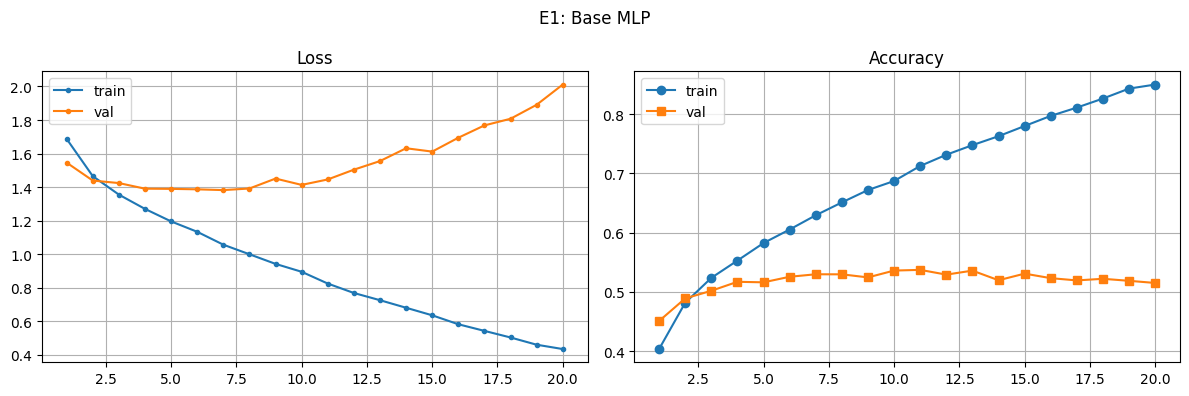

E2: MLP + Dropout
  Ep 01 | train: 1.8031/0.3547 | val: 1.5952/0.4459
  Ep 02 | train: 1.6298/0.4243 | val: 1.5154/0.4658
  Ep 03 | train: 1.5506/0.4545 | val: 1.4700/0.4899
  Ep 04 | train: 1.5027/0.4710 | val: 1.4424/0.4926
  Ep 05 | train: 1.4632/0.4813 | val: 1.4325/0.4972
  Ep 06 | train: 1.4251/0.4948 | val: 1.3838/0.5161
  Ep 07 | train: 1.3955/0.5046 | val: 1.3881/0.5045
  Ep 08 | train: 1.3642/0.5158 | val: 1.3638/0.5195
  Ep 09 | train: 1.3355/0.5264 | val: 1.3511/0.5270
  Ep 10 | train: 1.3178/0.5339 | val: 1.3412/0.5353
  Ep 11 | train: 1.2950/0.5412 | val: 1.3311/0.5362
  Ep 12 | train: 1.2777/0.5485 | val: 1.3185/0.5413
  Ep 13 | train: 1.2539/0.5519 | val: 1.3403/0.5392
  Ep 14 | train: 1.2393/0.5614 | val: 1.3179/0.5415
  Ep 15 | train: 1.2203/0.5658 | val: 1.2976/0.5500
  Ep 16 | train: 1.2057/0.5699 | val: 1.3069/0.5394
  Ep 17 | train: 1.1911/0.5764 | val: 1.3061/0.5465
  Ep 18 | train: 1.1716/0.5842 | val: 1.3026/0.5475
  Ep 19 | train: 1.1645/0.5804 | val: 1.3012/0

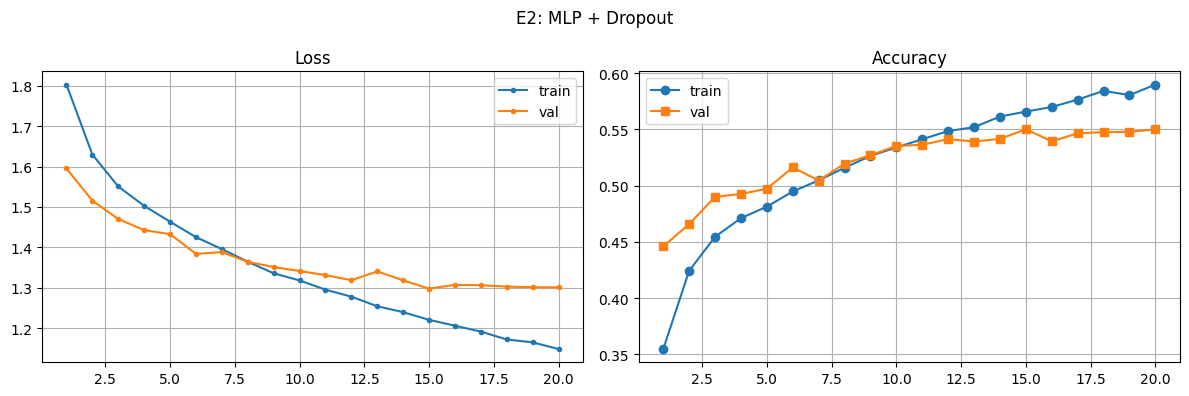

E3: MLP + BatchNorm
  Ep 01 | train: 1.6601/0.4129 | val: 1.5100/0.4647
  Ep 02 | train: 1.4247/0.4919 | val: 1.3971/0.5021
  Ep 03 | train: 1.3080/0.5352 | val: 1.3676/0.5148
  Ep 04 | train: 1.2270/0.5627 | val: 1.3454/0.5224
  Ep 05 | train: 1.1497/0.5939 | val: 1.3402/0.5325
  Ep 06 | train: 1.0897/0.6130 | val: 1.3253/0.5373
  Ep 07 | train: 1.0263/0.6396 | val: 1.3128/0.5347
  Ep 08 | train: 0.9704/0.6577 | val: 1.3469/0.5370
  Ep 09 | train: 0.9206/0.6746 | val: 1.3492/0.5347
  Ep 10 | train: 0.8680/0.6950 | val: 1.3705/0.5417
  Ep 11 | train: 0.8165/0.7138 | val: 1.3807/0.5406
  Ep 12 | train: 0.7622/0.7342 | val: 1.4403/0.5339
  Ep 13 | train: 0.7202/0.7488 | val: 1.4551/0.5419
  Ep 14 | train: 0.6757/0.7639 | val: 1.5162/0.5264
  Ep 15 | train: 0.6323/0.7804 | val: 1.5115/0.5349
  Ep 16 | train: 0.5851/0.7989 | val: 1.5810/0.5264
  Ep 17 | train: 0.5507/0.8094 | val: 1.5969/0.5264
  Ep 18 | train: 0.5104/0.8253 | val: 1.6271/0.5342
  Ep 19 | train: 0.4797/0.8370 | val: 1.6995

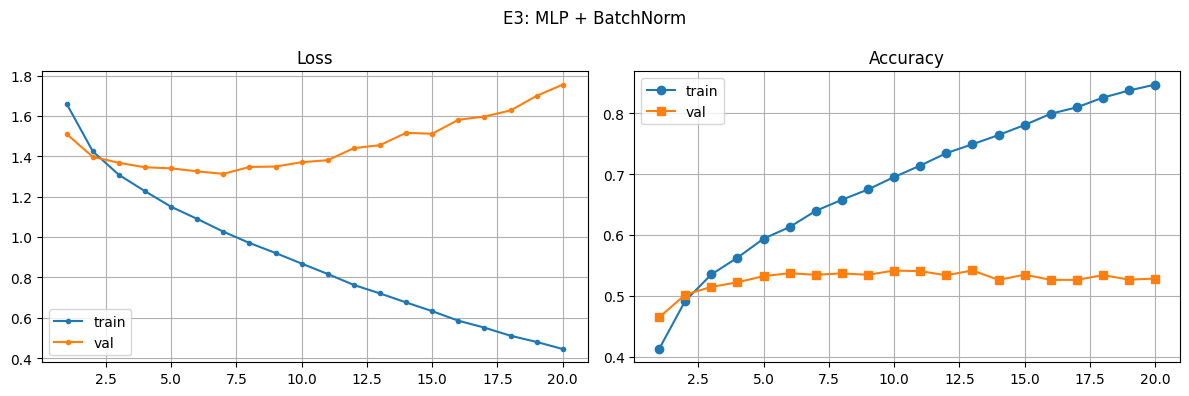

E4: EarlyStopping
E2 best val_acc: 0.5500
E3 best val_acc: 0.5419
Choosing E2 (Dropout) architecture
  Ep 01 | train: 1.8031/0.3547 | val: 1.5952/0.4459
  Ep 02 | train: 1.6298/0.4243 | val: 1.5154/0.4658
  Ep 03 | train: 1.5506/0.4545 | val: 1.4700/0.4899
  Ep 04 | train: 1.5027/0.4710 | val: 1.4424/0.4926
  Ep 05 | train: 1.4632/0.4813 | val: 1.4325/0.4972
  Ep 06 | train: 1.4251/0.4948 | val: 1.3838/0.5161
  Ep 07 | train: 1.3955/0.5046 | val: 1.3881/0.5045
  Ep 08 | train: 1.3642/0.5158 | val: 1.3638/0.5195
  Ep 09 | train: 1.3355/0.5264 | val: 1.3511/0.5270
  Ep 10 | train: 1.3178/0.5339 | val: 1.3412/0.5353
  Ep 11 | train: 1.2950/0.5412 | val: 1.3311/0.5362
  Ep 12 | train: 1.2777/0.5485 | val: 1.3185/0.5413
  Ep 13 | train: 1.2539/0.5519 | val: 1.3403/0.5392
  Ep 14 | train: 1.2393/0.5614 | val: 1.3179/0.5415
  Ep 15 | train: 1.2203/0.5658 | val: 1.2976/0.5500
  Ep 16 | train: 1.2057/0.5699 | val: 1.3069/0.5394
  Ep 17 | train: 1.1911/0.5764 | val: 1.3061/0.5465
  Ep 18 | train

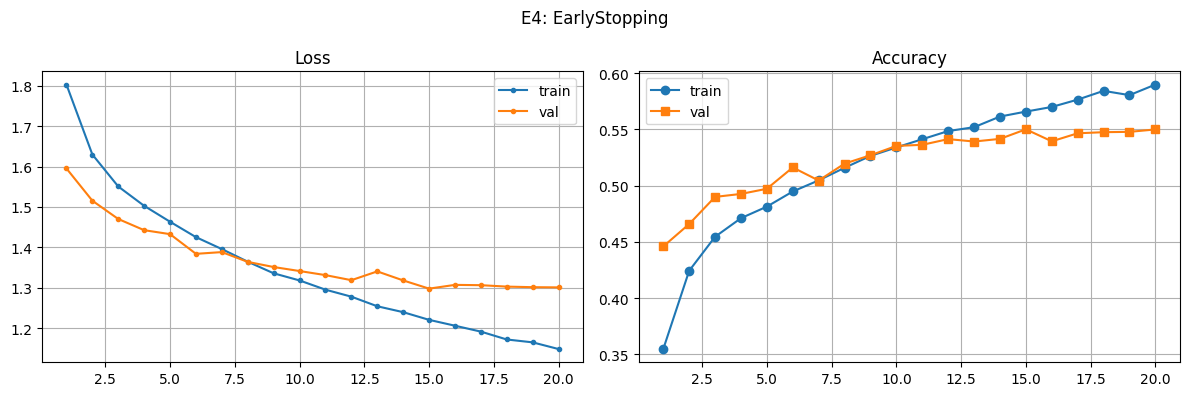

O1: LR too high (Adam lr=1e-1)
  Ep 01 | train: 14.1550/0.1007 | val: 2.3062/0.0979
  Ep 02 | train: 2.3965/0.0981 | val: 2.3060/0.1012
  Ep 03 | train: 2.3052/0.1004 | val: 2.3074/0.1005
  Ep 04 | train: 2.3062/0.1024 | val: 2.3084/0.0959
  Ep 05 | train: 2.3060/0.1002 | val: 2.3086/0.1000
  Ep 06 | train: 2.3108/0.0995 | val: 2.3050/0.0970
  Ep 07 | train: 2.3065/0.1002 | val: 2.3076/0.1000
  Ep 08 | train: 2.3061/0.0987 | val: 2.3084/0.0970


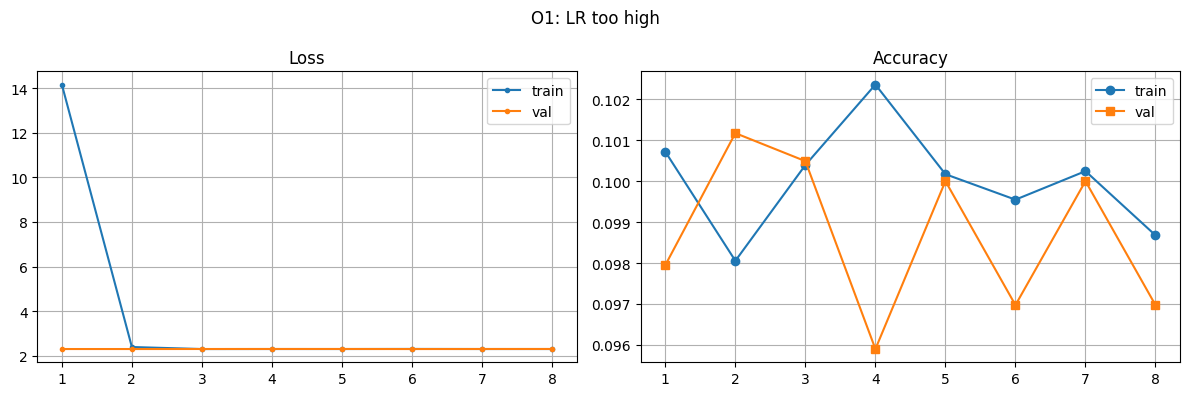

O2: LR too low (Adam lr=1e-5)
  Ep 01 | train: 2.2534/0.1943 | val: 2.1907/0.2590
  Ep 02 | train: 2.1474/0.2536 | val: 2.0874/0.2859
  Ep 03 | train: 2.0655/0.2766 | val: 2.0104/0.3111
  Ep 04 | train: 2.0077/0.2987 | val: 1.9504/0.3308
  Ep 05 | train: 1.9571/0.3114 | val: 1.9036/0.3440
  Ep 06 | train: 1.9217/0.3251 | val: 1.8667/0.3548
  Ep 07 | train: 1.8885/0.3360 | val: 1.8374/0.3632
  Ep 08 | train: 1.8656/0.3439 | val: 1.8135/0.3709


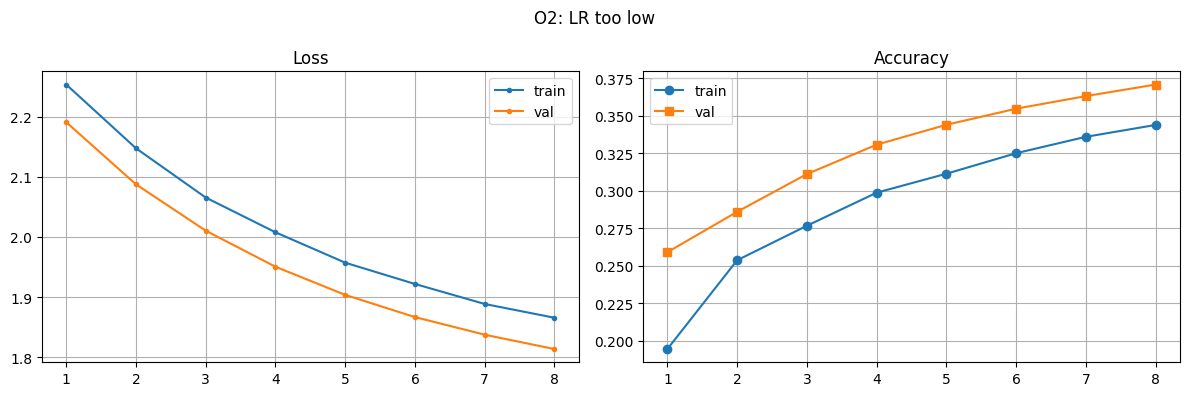

O3: SGD+momentum + weight_decay
  Ep 01 | train: 2.0245/0.2735 | val: 1.7830/0.3761
  Ep 02 | train: 1.7563/0.3772 | val: 1.6515/0.4204
  Ep 03 | train: 1.6605/0.4128 | val: 1.5756/0.4448
  Ep 04 | train: 1.6056/0.4353 | val: 1.5289/0.4602
  Ep 05 | train: 1.5512/0.4541 | val: 1.4905/0.4830
  Ep 06 | train: 1.5155/0.4692 | val: 1.4545/0.4890
  Ep 07 | train: 1.4771/0.4809 | val: 1.4305/0.4974
  Ep 08 | train: 1.4445/0.4907 | val: 1.4065/0.5076
  Ep 09 | train: 1.4163/0.5014 | val: 1.3866/0.5150
  Ep 10 | train: 1.3910/0.5071 | val: 1.3719/0.5207
  Ep 11 | train: 1.3630/0.5196 | val: 1.3598/0.5210
  Ep 12 | train: 1.3479/0.5266 | val: 1.3470/0.5276
  Ep 13 | train: 1.3249/0.5312 | val: 1.3426/0.5309
  Ep 14 | train: 1.3049/0.5397 | val: 1.3278/0.5350
  Ep 15 | train: 1.2880/0.5430 | val: 1.3152/0.5373


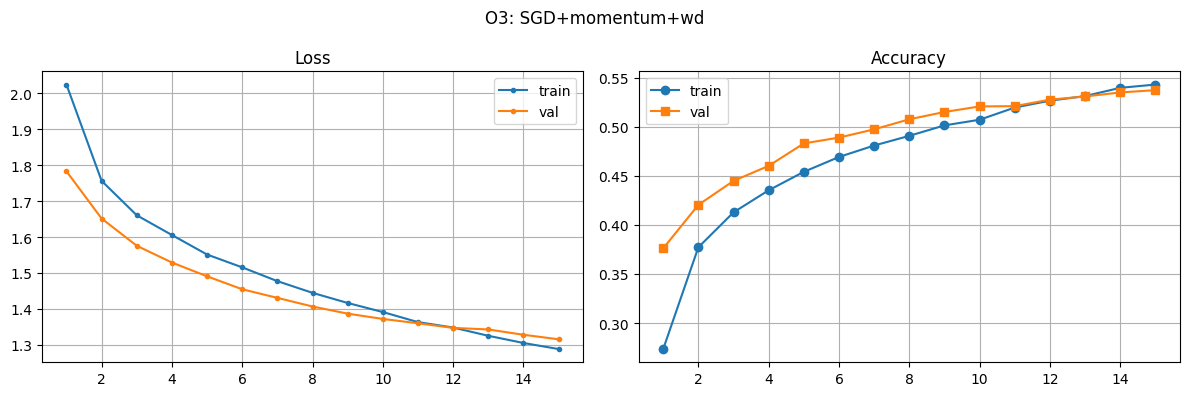

In [ ]:
print("E1: Base MLP")
set_seed(SEED)
m1 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=False).to(device)
h1 = fit(m1, train_loader, val_loader, optim.Adam(m1.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h1, "E1: Base MLP")

print("E2: MLP + Dropout")
set_seed(SEED)
m2 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=DROPOUT_P, use_batchnorm=False).to(device)
h2 = fit(m2, train_loader, val_loader, optim.Adam(m2.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h2, "E2: MLP + Dropout")

print("E3: MLP + BatchNorm")
set_seed(SEED)
m3 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=0.0, use_batchnorm=True).to(device)
h3 = fit(m3, train_loader, val_loader, optim.Adam(m3.parameters(), lr=LR_BASE), criterion, device, EPOCHS_BASE)
plot_history(h3, "E3: MLP + BatchNorm")

print("E4: EarlyStopping")
best_val_e2 = max(h2["val_acc"])
best_val_e3 = max(h3["val_acc"])
print(f"E2 best val_acc: {best_val_e2:.4f}")
print(f"E3 best val_acc: {best_val_e3:.4f}")

if best_val_e2 >= best_val_e3:
    print("Choosing E2 (Dropout) architecture")
    use_dropout, use_bn = DROPOUT_P, False
    model_summary = f"MLP+Dropout({DROPOUT_P})+EarlyStopping"
else:
    print("Choosing E3 (BatchNorm) architecture")
    use_dropout, use_bn = 0.0, True
    model_summary = "MLP+BatchNorm+EarlyStopping"

set_seed(SEED)
m4 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
es = EarlyStopping(patience=5)
h4 = fit(m4, train_loader, val_loader, optim.Adam(m4.parameters(), lr=LR_BASE), criterion, device, EPOCHS_ES, es)
plot_history(h4, "E4: EarlyStopping")

print("O1: LR too high (Adam lr=1e-1)")
set_seed(SEED)
m_o1 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o1 = fit(m_o1, train_loader, val_loader, optim.Adam(m_o1.parameters(), lr=1e-1), criterion, device, 8)
plot_history(h_o1, "O1: LR too high")

print("O2: LR too low (Adam lr=1e-5)")
set_seed(SEED)
m_o2 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o2 = fit(m_o2, train_loader, val_loader, optim.Adam(m_o2.parameters(), lr=1e-5), criterion, device, 8)
plot_history(h_o2, "O2: LR too low")

print("O3: SGD+momentum + weight_decay")
set_seed(SEED)
m_o3 = MLP(input_dim=INPUT_DIM, hidden_dims=HIDDEN_DIMS, num_classes=NUM_CLASSES, dropout_p=use_dropout, use_batchnorm=use_bn).to(device)
h_o3 = fit(m_o3, train_loader, val_loader, 
           optim.SGD(m_o3.parameters(), lr=1e-2, momentum=0.9, weight_decay=1e-4), 
           criterion, device, 15)
plot_history(h_o3, "O3: SGD+momentum+wd")

In [ ]:
results = [
    {"experiment_id": "E1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": f"MLP({INPUT_DIM}→256→128→{NUM_CLASSES})",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h1["val_acc"]),
     "best_val_accuracy": max(h1["val_acc"]), "best_val_loss": min(h1["val_loss"])},
    
    {"experiment_id": "E2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": f"MLP+Dropout({DROPOUT_P})",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h2["val_acc"]),
     "best_val_accuracy": max(h2["val_acc"]), "best_val_loss": min(h2["val_loss"])},
    
    {"experiment_id": "E3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": "MLP+BatchNorm",
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h3["val_acc"]),
     "best_val_accuracy": max(h3["val_acc"]), "best_val_loss": min(h3["val_loss"])},
    
    {"experiment_id": "E4", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": LR_BASE, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h4["val_acc"]),
     "best_val_accuracy": max(h4["val_acc"]), "best_val_loss": min(h4["val_loss"])},
    
    {"experiment_id": "O1", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": 1e-1, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h_o1["val_acc"]),
     "best_val_accuracy": max(h_o1["val_acc"]), "best_val_loss": min(h_o1["val_loss"])},
    
    {"experiment_id": "O2", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "Adam", "lr": 1e-5, "momentum": 0, "weight_decay": 0,
     "epochs_trained": len(h_o2["val_acc"]),
     "best_val_accuracy": max(h_o2["val_acc"]), "best_val_loss": min(h_o2["val_loss"])},
    
    {"experiment_id": "O3", "dataset": DATASET_NAME, "seed": SEED,
     "model_summary": model_summary,
     "optimizer": "SGD", "lr": 1e-2, "momentum": 0.9, "weight_decay": 1e-4,
     "epochs_trained": len(h_o3["val_acc"]),
     "best_val_accuracy": max(h_o3["val_acc"]), "best_val_loss": min(h_o3["val_loss"])}
]

df_results = pd.DataFrame(results)
df_results.to_csv("artifacts/runs.csv", index=False)
print("Saved: artifacts/runs.csv")
print(df_results[["experiment_id", "best_val_accuracy", "best_val_loss"]])

Saved: artifacts/runs.csv
  experiment_id  best_val_accuracy  best_val_loss
0            E1           0.537207       1.382441
1            E2           0.550000       1.297563
2            E3           0.541895       1.312817
3            E4           0.550000       1.297563
4            O1           0.101172       2.305048
5            O2           0.370898       1.813523
6            O3           0.537305       1.315204


In [ ]:
torch.save(m4.state_dict(), "artifacts/best_model.pt")
print("Saved: artifacts/best_model.pt")

config = {
    "experiment_id": "E4",
    "dataset": DATASET_NAME,
    "seed": SEED,

    "architecture": {
        "input_dim": INPUT_DIM,
        "hidden_dims": HIDDEN_DIMS,
        "num_classes": NUM_CLASSES,
        "dropout_p": use_dropout,
        "use_batchnorm": use_bn
    },
    "training": {
        "optimizer": "Adam",
        "lr": LR_BASE,
        "momentum": 0,
        "weight_decay": 0,
        "batch_size": BATCH_SIZE,
        "max_epochs": EPOCHS_ES,
        "early_stopping_patience": 5,
        "criterion": "CrossEntropyLoss"
    },
    "results": {
        "best_val_accuracy": float(max(h4["val_acc"])),
        "best_val_loss": float(min(h4["val_loss"])),
        "epochs_trained": len(h4["val_acc"])
    }
}
with open("artifacts/best_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Saved: artifacts/best_config.json")

Saved: artifacts/best_model.pt
Saved: artifacts/best_config.json


In [ ]:
epochs = range(1, len(h4["train_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, h4["train_loss"], label="train", marker="o")
plt.plot(epochs, h4["val_loss"], label="val", marker="s")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs, h4["train_acc"], label="train", marker="o")
plt.plot(epochs, h4["val_acc"], label="val", marker="s")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.suptitle(f"E4: Best Model (val_acc={max(h4['val_acc']):.4f})")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_best.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: artifacts/figures/curves_best.png")

Saved: artifacts/figures/curves_best.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_o1 = range(1, len(h_o1["train_loss"]) + 1)
axes[0].plot(epochs_o1, h_o1["train_loss"], label="train", marker="o")
axes[0].plot(epochs_o1, h_o1["val_loss"], label="val", marker="s")
axes[0].set_title(f"O1: LR too high (1e-1)\nval_acc={max(h_o1['val_acc']):.4f}")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

epochs_o2 = range(1, len(h_o2["train_loss"]) + 1)
axes[1].plot(epochs_o2, h_o2["train_loss"], label="train", marker="o")
axes[1].plot(epochs_o2, h_o2["val_loss"], label="val", marker="s")
axes[1].set_title(f"O2: LR too low (1e-5)\nval_acc={max(h_o2['val_acc']):.4f}")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid()

plt.suptitle("LR Diagnostics: Too High vs Too Low", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("artifacts/figures/curves_lr_extremes.png", dpi=300, bbox_inches="tight")
plt.close()
print("Saved: artifacts/figures/curves_lr_extremes.png")

Saved: artifacts/figures/curves_lr_extremes.png


In [ ]:
print("FINAL TEST EVALUATION (E4)")
test_loss, test_acc = evaluate(m4, test_loader, criterion, device)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

print("HW08-09 COMPLETED!")
print(f"Best model: E4")
print(f"Best val_acc: {max(h4['val_acc']):.4f}")
print(f"Test acc: {test_acc:.4f}")

FINAL TEST EVALUATION (E4)
Test Accuracy: 0.5380
Test Loss: 1.3001
HW08-09 COMPLETED!
Best model: E4
Best val_acc: 0.5500
Test acc: 0.5380
